In [1]:
%matplotlib inline
import warnings
import time
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import brainstate
import braintools
import brainunit as u
import brainmass
from brainmass import objectives
from brainstate.nn import Param
brainstate.environ.set(dt=0.1 * u.ms)
brainstate.random.seed(0)


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Choose a Model

**Goal:** pick the right neural-mass model for your research question, fast.

`brainmass` ships ~20 models. This recipe gives you a *programmatic* catalogue
(`brainmass.list_models`), a short decision guide, and a couple of one-liners to
sanity-check a candidate before committing. For the full reference see
{doc}`/reference/models`; to see models running, browse the
{doc}`/gallery/index`.


## Browse the catalogue

`brainmass.list_models()` returns one typed `ModelInfo` record per user-facing
model — name, category, number of state variables, and a one-line use case. It is
dependency-free and pleasant to scan in the REPL.


In [2]:
records = brainmass.list_models()
print(f"{len(records)} models")
print(brainmass.list_models.to_table())

20 models
name                     category          #states  use_case                                 
-----------------------  ----------------  -------  -----------------------------------------
HopfStep                 phenomenological  2        Oscillation onset, rhythm generation     
VanDerPolStep            phenomenological  2        Nonlinear relaxation oscillations        
StuartLandauStep         phenomenological  2        Amplitude-controlled oscillations        
FitzHughNagumoStep       phenomenological  2        Excitability, spike generation           
ThresholdLinearStep      phenomenological  2        Fast linear E-I responses                
Generic2dOscillatorStep  phenomenological  2        Flexible planar dynamics (TVB)           
LorenzStep               phenomenological  3        Chaos, coupling test fixture             
LinearStep               phenomenological  1        Baseline node, coupling sanity checks    
WilsonCowanStep          physiological     2      

Each record is a `NamedTuple`, so you can filter it like ordinary data — for
example, "show me every physiological model with at most 3 state variables":


In [3]:
cheap_physio = [
    m for m in records
    if m.category == 'physiological' and m.n_state_vars <= 3
]
for m in cheap_physio:
    print(f"{m.name:24s} {m.n_state_vars} vars  -  {m.use_case}")

WilsonCowanStep          2 vars  -  E-I population firing-rate dynamics
WongWangStep             2 vars  -  Decision making (perceptual choice)
WongWangExcInhStep       2 vars  -  Resting-state BOLD/FC, E-I balance
MontbrioPazoRoxinStep    2 vars  -  Exact QIF mean-field (theta neurons)
CoombesByrneStep         2 vars  -  Next-gen mean-field, conductance synapses
LarterBreakspearStep     3 vars  -  Conductance-based limit cycles / chaos


The three categories are:

- **`phenomenological`** — generic dynamical systems (Hopf, FitzHugh-Nagumo,
  Stuart-Landau, …). Cheap, interpretable, great for studying bifurcations and
  synchronization.
- **`physiological`** — biophysically grounded mean-field models (Jansen-Rit,
  Wilson-Cowan, Wong-Wang, Montbrió-Pazó-Roxin, …). Use when you need to link to a
  neural mechanism or a recording modality.
- **`network`** — models that *are* a network of units (Kuramoto, the HORN family).


In [4]:
from collections import Counter
counts = Counter(m.category for m in records)
print(dict(counts))

{'phenomenological': 8, 'physiological': 8, 'network': 4}


## A decision guide

Walk these three axes — **dynamics regime**, **number of variables / cost**, and
**signal type** — and the catalogue narrows quickly.

```text
What are you studying?
├─ Generic dynamics (bifurcation, synchrony) ──► phenomenological
│   ├─ oscillation onset / rhythms ............ HopfStep, StuartLandauStep
│   ├─ excitability / spikes .................. FitzHughNagumoStep
│   ├─ phase synchronization ................... KuramotoNetwork
│   └─ a flexible planar node (TVB) ........... Generic2dOscillatorStep
│
└─ A specific neural mechanism / modality ──── physiological
    ├─ EEG / MEG, alpha rhythms .............. JansenRitStep   (6 vars)
    ├─ resting-state fMRI BOLD / FC .......... WongWangExcInhStep, WilsonCowanStep
    ├─ E-I population balance ................ WilsonCowanStep
    ├─ exact spiking mean-field .............. MontbrioPazoRoxinStep, CoombesByrneStep
    └─ seizures / epilepsy ................... EpileptorStep
```

Three quick rules of thumb:

1. **Match the timescale to the data.** Jansen-Rit (τ ≈ 10 ms) is right for EEG;
   Wong-Wang (τ ≈ 100 ms) is right for fMRI. A mismatch shows up as the wrong
   spectral peak.
2. **Match the observable.** EEG/MEG needs a model with an explicit membrane
   potential (Jansen-Rit `eeg()`); BOLD needs slow synaptic dynamics
   (`WongWangExcInhStep`, `WilsonCowanStep`) feeding a hemodynamic model.
3. **Start cheap.** Fewer state variables → faster runs and a smoother fitting
   landscape. Add complexity only when a simpler model demonstrably can't fit.

:::{note}
For resting-state BOLD use **`WongWangExcInhStep`** (the Deco-2014 excitatory /
inhibitory model with `S_E`/`S_I` states). `WongWangStep` is the *reduced
decision-making* model (`S1`/`S2`) — a different model with the same surname.
:::


## Sanity-check a candidate

Every node model has the same contract: construct it with `in_size=N`, then drive
it with a `brainmass.Simulator`. No hand-written loop is needed — the simulator
compiles the run for you. Here is a cheap phenomenological pick (Hopf) for 90
regions.


In [5]:
hopf = brainmass.HopfStep(
    in_size=90,
    w=0.1,   # intrinsic angular frequency (dimensionless)
    a=0.25,  # > 0 for a stable limit cycle
)
res = brainmass.Simulator(hopf, dt=0.1 * u.ms).run(
    300 * u.ms, monitors=['x'], transient=50 * u.ms,
)
print("Hopf trace:", res['x'].shape, " (time, regions)")

Hopf trace: (2500, 90)  (time, regions)


A physiological pick costs more per region — Jansen-Rit integrates 6 state
variables — but the *call* is identical, which is the whole point of the model
contract. Here `eeg()` is the derived pyramidal observable you would feed a
lead-field.


In [6]:
jr = brainmass.JansenRitStep(in_size=8)  # 8 cortical sources
res = brainmass.Simulator(jr, dt=0.1 * u.ms).run(
    400 * u.ms, monitors=lambda m: m.eeg(), transient=100 * u.ms,
)
print("Jansen-Rit EEG observable:", res['output'].shape)
print("n_state_vars (from catalogue):",
      next(m.n_state_vars for m in records if m.name == 'JansenRitStep'))

Jansen-Rit EEG observable: (3000, 8)
n_state_vars (from catalogue): 6


## Compare candidates side by side

Because the run API is uniform, comparing two models is just two `Simulator`
calls. Here a cheap oscillator (Hopf) and an excitable node (FitzHugh-Nagumo) are
each driven for the same duration; we plot one region of each.


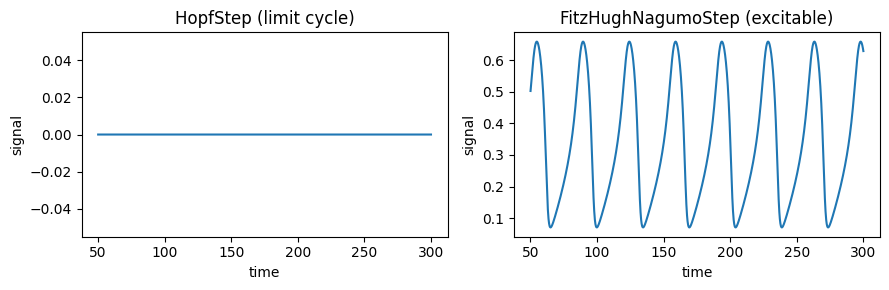

In [7]:
hopf = brainmass.HopfStep(in_size=1, a=0.25, w=0.3)
fhn = brainmass.FitzHughNagumoStep(in_size=1)

r_hopf = brainmass.Simulator(hopf, dt=0.1 * u.ms).run(
    300 * u.ms, monitors=['x'], transient=50 * u.ms)
r_fhn = brainmass.Simulator(fhn, dt=0.1 * u.ms).run(
    300 * u.ms, monitors=['V'], transient=50 * u.ms,
    inputs=lambda i, t: 0.8)  # constant drive into the excitable regime

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
brainmass.viz.plot_timeseries(r_hopf['x'], ts=r_hopf['ts'], ax=axes[0])
axes[0].set_title('HopfStep (limit cycle)')
brainmass.viz.plot_timeseries(r_fhn['V'], ts=r_fhn['ts'], ax=axes[1])
axes[1].set_title('FitzHughNagumoStep (excitable)')
fig.tight_layout()
plt.show()

## Common pitfalls

- **Reaching for a complex model too early.** More parameters means a harder
  optimization with more local minima. Start with `HopfStep` or
  `WilsonCowanStep`, validate, then add complexity.
- **Mismatched observable.** Fitting a BOLD target with a model that has no slow
  synaptic dynamics will never work — check the *signal type* axis first.
- **Ignoring cost.** A 6-variable Jansen-Rit network is ~3× the work of a
  2-variable Hopf network of the same size; for exploratory sweeps prefer the
  cheaper node.

## Next steps

- {doc}`/tutorials/04_building_a_network` — wire your chosen model into a network.
- {doc}`/tutorials/06_fitting_with_gradients` — fit its parameters.
- {doc}`/reference/models` — the full per-model reference.
- {doc}`/gallery/index` — every model running end to end.
